# Customer Behaviour Prediction Model CA by Charlie Coad 20102084 

## Introduction

#### I have been hired by a Retail Business as a Business Data Analyst, where I have been tasked with creating a Machine Learning Model that can identify the likelihood that a customer will return to their online retail website or not based on the characteristics and behaviour of that customer. This is because this business wants to understand human behaviour and what will influence them to return to their business’s website, as customers are most likely to purchase from the website if they are returning frequently. By identifying these patterns, the business can better look at the trends that contribute to customers that are not returning and make business decisions to correct or fix them going forward.

#### I will be aiming to utilise and experiment with different Machine Learning models, techniques and algorithms to identify the optimal churn prediction model that will provide me with the least bias and the most accurate results. In addition to this, this analysis will also aim to examine the different groups of variables that are heavily influencing the models prediction in order to understand which variables are having the greatest impact on customer’s behaviour to return to the website.

-----------------------------------------------------------------------------------------------------------------------------------------------------

## Exploratory Data Analysis (EDA)

### Data Preparation

#### One of the most important things we do to begin any data analysis is to prepare and clean the data first. To begin my Analysis, I first installed and loaded in a majority of the libraries, classifiers graph creators, machine learning models, evaluation metrics’ that I would need for my analysis. I decided to install a majority of these first so that I could get started in these areas straight away and I believed it was more efficient processing wise. 

In [1]:
# Load libraries
import pandas as pd
from sklearn.ensemble import GradientBoostingClassifier# Importing the Gradient Bagging Classifier
from sklearn.tree import DecisionTreeClassifier # Import Decision Tree Classifier
from sklearn.model_selection import train_test_split # Import train_test_split function
from sklearn import metrics #Import scikit-learn metrics module for accuracy calculation
import numpy as np # Importing Numpy, Seaborn and Matplotlib for creating graphs
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, LogisticRegression #Importing Linear and Logistical Regression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    classification_report,
    confusion_matrix # Importing Evaluation metrics
)
from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import ConfusionMatrixDisplay
%matplotlib inline
!pip install imbalanced-learn


Defaulting to user installation because normal site-packages is not writeable


#### Next I will load in my Customer Behaviour Dataset and looking at the different columns I have.

In [2]:
# load dataset
df = pd.read_csv("customer_behavior_dataset_CA.csv")
df.columns

Index(['Order_ID', 'Customer_ID', 'Date', 'Age', 'Gender', 'City',
       'Product_Category', 'Unit_Price', 'Quantity', 'Discount_Amount',
       'Total_Amount', 'Payment_Method', 'Device_Type',
       'Session_Duration_Minutes', 'Pages_Viewed', 'Is_Returning_Customer',
       'Delivery_Time_Days', 'Customer_Rating'],
      dtype='object')

#### Next I loaded in my Customer Behaviour Dataset and looking at the different columns I hav. This gives me a much better visual look at the database.

In [3]:
df.head(5)

,Order_ID,Customer_ID,Date,Age,Gender,City,Product_Category,Unit_Price,Quantity,Discount_Amount,Total_Amount,Payment_Method,Device_Type,Session_Duration_Minutes,Pages_Viewed,Is_Returning_Customer,Delivery_Time_Days,Customer_Rating
0,ORD_000001-1,CUST_00001,2023-05-29,40,Male,Ankara,Books,29.18,1,0.00,29.18,Digital Wallet,Mobile,14,9,True,13,4
1,ORD_000001-2,CUST_00001,2023-10-12,40,Male,Ankara,Home & Garden,644.40,1,138.05,506.35,Credit Card,Desktop,14,8,True,6,2
2,ORD_000001-3,CUST_00001,2023-12-05,40,Male,Ankara,Sports,332.82,5,0.00,1664.10,Credit Card,Mobile,15,10,True,9,4
3,ORD_000002-1,CUST_00002,2023-05-11,33,Male,Istanbul,Food,69.30,5,71.05,275.45,Digital Wallet,Desktop,16,13,True,4,4
4,ORD_000002-2,CUST_00002,2023-06-16,33,Male,Istanbul,Beauty,178.15,3,0.00,534.45,Credit Card,Mobile,14,7,True,6,4


#### After this I needed to get a better look into how the data was structured, what data types it had and its shape. 

In [4]:
df.describe(include='all')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17049 entries, 0 to 17048
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Order_ID                  17049 non-null  object 
 1   Customer_ID               17049 non-null  object 
 2   Date                      17049 non-null  object 
 3   Age                       17049 non-null  int64  
 4   Gender                    17049 non-null  object 
 5   City                      17049 non-null  object 
 6   Product_Category          17049 non-null  object 
 7   Unit_Price                17049 non-null  float64
 8   Quantity                  17049 non-null  int64  
 9   Discount_Amount           17049 non-null  float64
 10  Total_Amount              17049 non-null  float64
 11  Payment_Method            17049 non-null  object 
 12  Device_Type               17049 non-null  object 
 13  Session_Duration_Minutes  17049 non-null  int64  
 14  Pages_

#### What we can derive here is that there are 17049 rows and 18 columns, 

In [5]:
df.shape

(17049, 18)

#### Next I decided I needed to drop all the Index columns, those being “Customer_ID”, “Order_ID” and “Date” I dropped these because they are identifiers and do not have weight/influence in if a customers returns or not to the website. 

In [6]:
df = df.drop(["Customer_ID", "Order_ID", "Date"], axis=1)
df.head()

,Age,Gender,City,Product_Category,Unit_Price,Quantity,Discount_Amount,Total_Amount,Payment_Method,Device_Type,Session_Duration_Minutes,Pages_Viewed,Is_Returning_Customer,Delivery_Time_Days,Customer_Rating
0,40,Male,Ankara,Books,29.18,1,0.00,29.18,Digital Wallet,Mobile,14,9,True,13,4
1,40,Male,Ankara,Home & Garden,644.40,1,138.05,506.35,Credit Card,Desktop,14,8,True,6,2
2,40,Male,Ankara,Sports,332.82,5,0.00,1664.10,Credit Card,Mobile,15,10,True,9,4
3,33,Male,Istanbul,Food,69.30,5,71.05,275.45,Digital Wallet,Desktop,16,13,True,4,4
4,33,Male,Istanbul,Beauty,178.15,3,0.00,534.45,Credit Card,Mobile,14,7,True,6,4


#### Next I take a look at what column data types I have here:

In [7]:
df.dtypes

Age                           int64
Gender                       object
City                         object
Product_Category             object
Unit_Price                  float64
Quantity                      int64
Discount_Amount             float64
Total_Amount                float64
Payment_Method               object
Device_Type                  object
Session_Duration_Minutes      int64
Pages_Viewed                  int64
Is_Returning_Customer          bool
Delivery_Time_Days            int64
Customer_Rating               int64
dtype: object

#### Since I am utilising Pandas I want to create specific visuals however I cannot do this if my columns are classified as objects. Therefore I utilised the select_dtypes function to identify all the columns that were classified as an “object” and changed them to a categorical data type: 

#### As we can see, all of our integer and float data types are defined however since we are using Pandas and in order to create specific visuals. im going to change the datatypes of my columns where they are currently defined as an object into a category. 

#### This will be periodically as I will be turning these into integers for the machine learning section.

In [8]:
# This code allows us to select all of the columns with object as the datatype
object_cols = df.select_dtypes(include=['object']).columns
# This code converts them into a category
df[object_cols] = df[object_cols].astype('category')
print(df.dtypes)

Age                            int64
Gender                      category
City                        category
Product_Category            category
Unit_Price                   float64
Quantity                       int64
Discount_Amount              float64
Total_Amount                 float64
Payment_Method              category
Device_Type                 category
Session_Duration_Minutes       int64
Pages_Viewed                   int64
Is_Returning_Customer           bool
Delivery_Time_Days             int64
Customer_Rating                int64
dtype: object


#### I then checked for any duplicated data, using “duplicated.sum” and if there were any null values using the “isnull()” action.  However it was identified there was no duplicated data or null values. This now tells us that the dataset is clean and I am now ready to conduct a deeper analysis on it. 

In [9]:
df.duplicated().sum

<bound method Series.sum of 0        False
1        False
2        False
3        False
4        False
         ...  
17044    False
17045    False
17046    False
17047    False
17048    False
Length: 17049, dtype: bool>

#### Next lets identify if there are any null values in this dataset, however we can see here I do not have any null values.

In [10]:
print(df.isnull().sum())

Age                         0
Gender                      0
City                        0
Product_Category            0
Unit_Price                  0
Quantity                    0
Discount_Amount             0
Total_Amount                0
Payment_Method              0
Device_Type                 0
Session_Duration_Minutes    0
Pages_Viewed                0
Is_Returning_Customer       0
Delivery_Time_Days          0
Customer_Rating             0
dtype: int64


-----------------------------------------------------------------------------------------------------------------------------------------------------

### Outlier Detection:

#### Lets check for any outliers within this dataset, I will be using seaborn to generate boxplots based on different variables in order to see their distribution.

#### Here im utilising Boxplots from my Seaborn library to create boxplot graphs showcasing the Age column from my dataset

<Axes: xlabel='Age'>

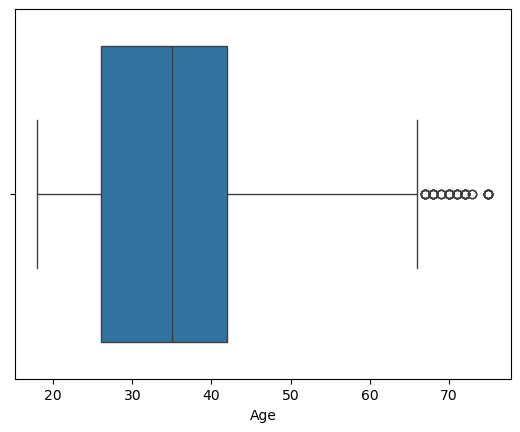

In [11]:
sns.boxplot(x=df['Age'])

#### This boxplot tells us that most of our age group ranges from roughly 25-40 on average with outliers to the right indicating we have a few online users that are over 65.

#### Here im utilising Boxplots from my Seaborn library to create boxplot graphs showcasing the Unit Price column from my dataset

<Axes: xlabel='Unit_Price'>

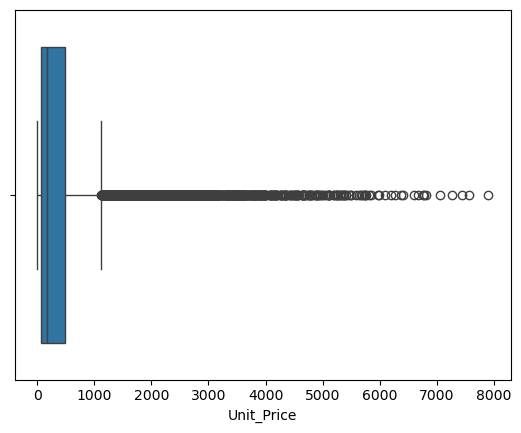

In [12]:
sns.boxplot(x=df['Unit_Price'])

#### Here im utilising Boxplots from my Seaborn library to create boxplot graphs showcasing the Total Amount column from my dataset

<Axes: xlabel='Total_Amount'>

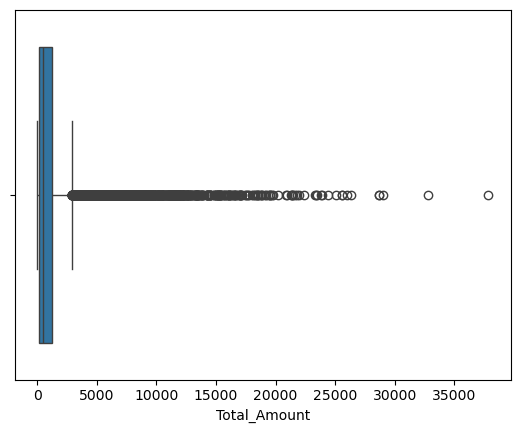

In [13]:
sns.boxplot(x=df["Total_Amount"])

#### We can interpret from our Boxplots above that our data is has a Right Skewed Distribution. Indicated by its long tail going to the right. This tells us that our dataset contains few very large values.

### Descriptive Statistics:

#### Now I will look at descriptive statistics of the dataset. I utilised the describe function and included all the columns into the one table to make it easier to visualise. 

#### Interesting to note that looking at our numerical data:  The average age is 35 which tells us that mostly young adults are shopping here, we can also see that most people are spending roughly 1277 dollars on their shopping and their review score is a 3.8 out of 5.
#### On the categorical data side we can see that this dataset mostly consists of Females, with a majority of the customers being from Instanbull and most customers purchasing items from the Sports section. Finally we can see that most of our customers are returning customers.

In [14]:
df.describe(include='all')

,Age,Gender,City,Product_Category,Unit_Price,Quantity,Discount_Amount,Total_Amount,Payment_Method,Device_Type,Session_Duration_Minutes,Pages_Viewed,Is_Returning_Customer,Delivery_Time_Days,Customer_Rating
count,17049.000000,17049,17049,17049,17049.000000,17049.000000,17049.000000,17049.000000,17049,17049,17049.000000,17049.000000,17049,17049.000000,17049.000000
unique,NaN,3,10,8,NaN,NaN,NaN,NaN,5,3,NaN,NaN,2,NaN,NaN
top,NaN,Female,Istanbul,Sports,NaN,NaN,NaN,NaN,Credit Card,Mobile,NaN,NaN,True,NaN,NaN
freq,NaN,8613,4402,2248,NaN,NaN,NaN,NaN,6801,9543,NaN,NaN,15039,NaN,NaN
mean,34.945745,NaN,NaN,NaN,447.901689,3.011379,69.788135,1277.438711,NaN,NaN,14.535633,9.003109,NaN,6.503607,3.899408
std,11.046855,NaN,NaN,NaN,722.319705,1.417027,240.704662,2358.436375,NaN,NaN,2.925524,2.259954,NaN,3.488787,1.128803
min,18.000000,NaN,NaN,NaN,5.050000,1.000000,0.000000,6.210000,NaN,NaN,4.000000,1.000000,NaN,1.000000,1.000000
25%,26.000000,NaN,NaN,NaN,73.260000,2.000000,0.000000,172.970000,NaN,NaN,13.000000,7.000000,NaN,4.000000,3.000000
50%,35.000000,NaN,NaN,NaN,174.680000,3.000000,0.000000,455.850000,NaN,NaN,15.000000,9.000000,NaN,6.000000,4.000000
75%,42.000000,NaN,NaN,NaN,494.570000,4.000000,32.710000,1267.750000,NaN,NaN,17.000000,11.000000,NaN,8.000000,5.000000


## Visualisations and Pattern Revealing
### Correlation Heatmap

#### Below we can see that the Unit Price, Quantity, Discount Amount and Total Amount all have a correlation between one another however the rest of the columns do not, which is to be expected

#### To create this visual i decided to create my Correlation function, here i created a value where I only wanted to include the columns that contained Integers and floats because categorical data cannot be correlated in this graph. I then set my figure size to be 10,8, when i pulled the heatmap from my seaborn library i needed to define that it was correlating the numerical figures in my dataset, setting annot to True and wanting the map to having a visual colour correlation to coolwarm which meant that highly correlated figures would turn a warmer colour and uncorrelated figures would go a colder colour.

#### Patterns revealed in this chart is that Unit Price, Quanity, Discount Amount and Total Amount all have a correlation between one another however the rest of the columns do not, which is to be expected. Below we can see that the Unit Price, Quantity, Discount Amount and Total Amount all have a correlation between one another however the rest of the columns do not, which is to be expected


In [15]:
# The lighter the correlation, the stronger the correlation and the darker the weaker the correlation.
# Correlation cannot be found between object/categorical data types. 

def correlation(df):
    numeric_df = df.select_dtypes(include=['int64','float64'])
    plt.figure(figsize=(10,8))
    sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
    plt.title("Correlation Heatmap")
    plt.show()

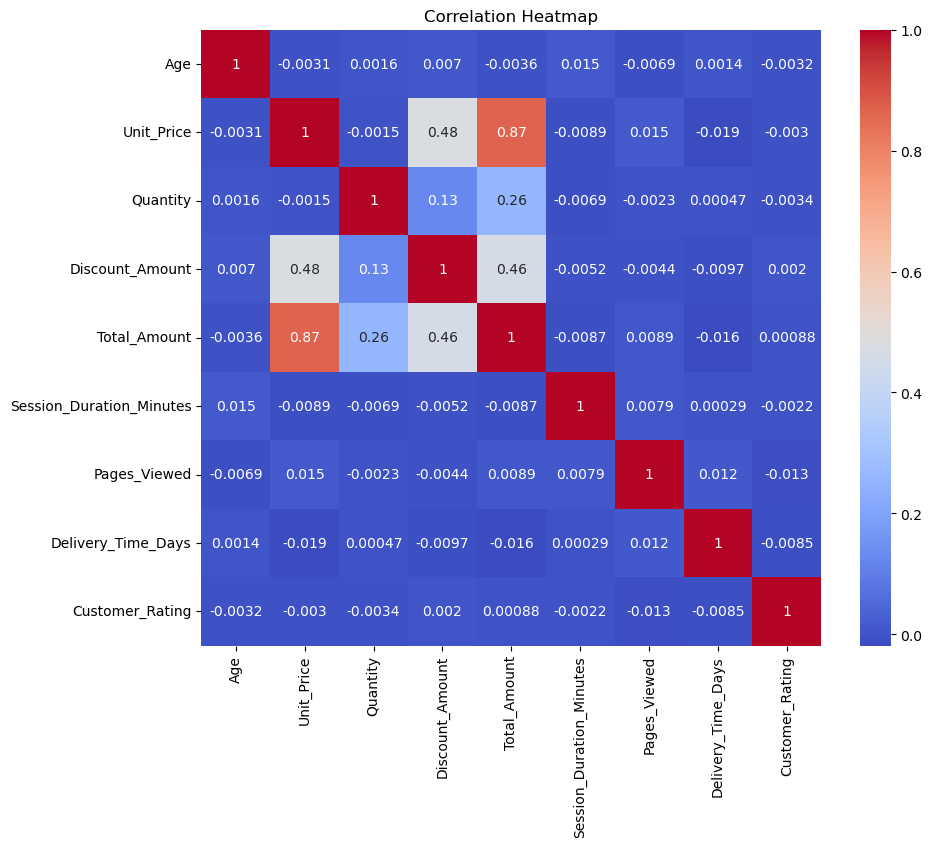

In [16]:
correlation(df)

### Count Graph: Returning customers vs none returning

#### Below I created a boxplot graph to visualise my classifier

#### I have used seaborn in order to create a count graph of the distribution between my returning and non returning customers. As we can see in the graph over 15000 customers are returning and just under 2000 are not

#### Patterns we can see in this graph include: roughly 15,000 of the customers will return while roughly 2,000 are not. This highlights a major issue in this classifier within this dataset. This is because it is highly unbalanced. This means that it will make accuracy misleading when we create our models.  However this is typically seen in most dataset and will mean that when we use our training and testing data it is very important to make appropriate samples to accommodate this.

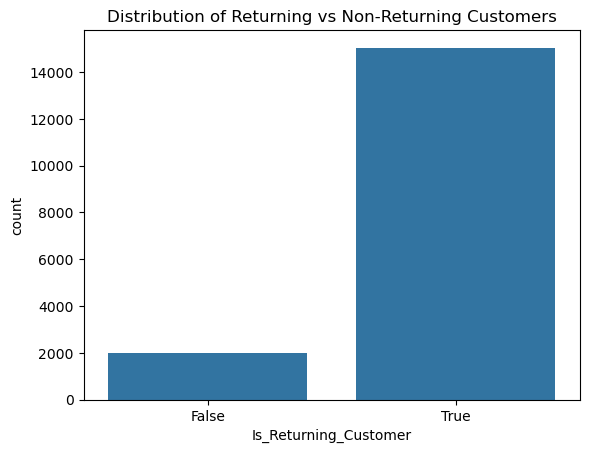

In [17]:
sns.countplot(x="Is_Returning_Customer", data=df)
plt.title("Distribution of Returning vs Non-Returning Customers")
plt.show()

### Count graph: Devices vs returning Customers
#### In this Count graph lets investigate what devices are returning customers using?

#### Here I utilised seaborn to create another count graph that looks at the distributions of both my Returning customers vs the Device types used. I did this by setting device type as x and hue as returning customers.

#### Patterns we can see in this data is that most customers are viewing this website on their phones. We can also see that most non-returning customers are using their laptop. 

<Axes: xlabel='Device_Type', ylabel='count'>

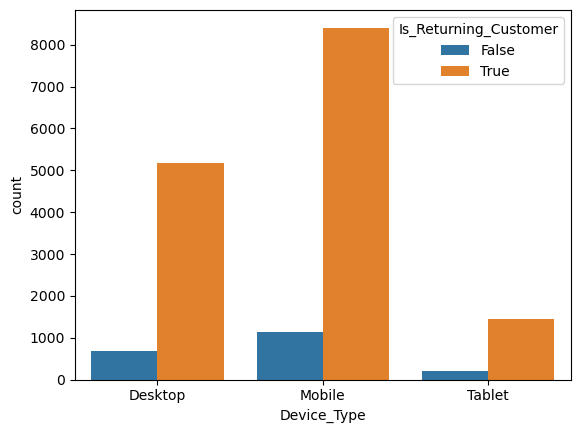

In [18]:
sns.countplot(x="Device_Type", hue="Is_Returning_Customer", data=df)

### Histogram: Gender Distribution:

#### In this model I have created a Gender Pie chart where I utilise the MatplotLib library to pull the pie chart figure from.
#### I am calling the Gender column and using the value_counts function to coulnt the values. Then inserting the function into the chart and titling it. I am also using the autopct to create text and figures to give further information on the graph.
#### Patterns we can see from this graph include: Most customers are female, at 50.5%, while the males make up 48.0% and the remainder of customers go by other at 1.5% 

<function matplotlib.pyplot.show(close=None, block=None)>

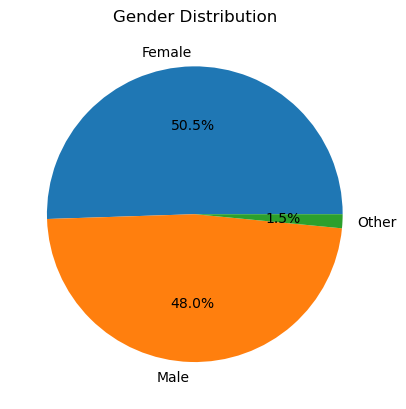

In [19]:
gender_counts = df['Gender'].value_counts()

plt.figure()
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%')
plt.title('Gender Distribution')
plt.show

### Histogram: Age Distribution:
#### Next lets take a look at Age Distribution where Im calling the histrogram figure from the seaborn library and inserting the Age column. I then set the bins as 20 to give us a better idea of the overall distribution

#### Patterns we can gather from this graph is that there seems to be a large amount of young people and middle-aged users interacting with the sight however we can see that after the age of 40, the distribution begins to decrease. 

<Axes: xlabel='Age', ylabel='Count'>

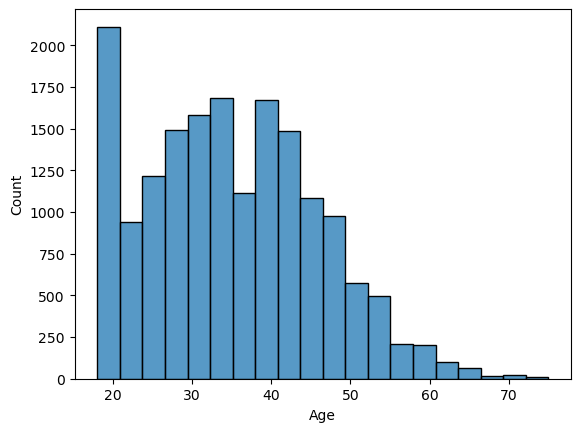

In [20]:
sns.histplot(df['Age'], bins=20)


### Histogram: Review Rating Distribution
#### Next I apply a similar distribution to the Customer_Rating column.

#### This graph details how the customer reviews are mostly positive ranging mostly from 3-5, however there are still a chunk of negative reviews that should also be consider. 

<Axes: xlabel='Customer_Rating', ylabel='Count'>

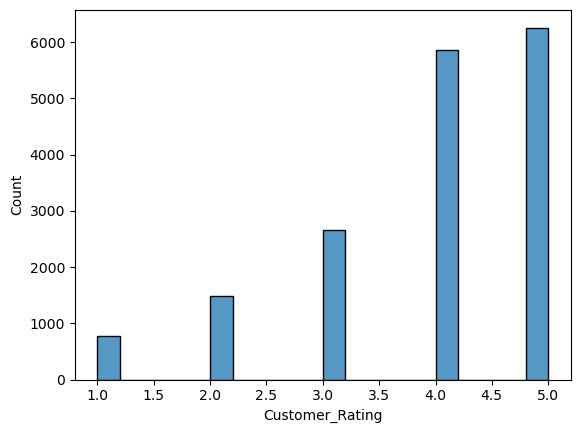

In [21]:
sns.histplot(df['Customer_Rating'], bins=20)

### Bivariate Analysis: Returning Customer by Product Category:

 #### To create the code for this visual, I first begin setting my figure at 10,6 to determine the size of my graph. I created this graph utilising Seaborn to create a count graph that looks at my returning customers by the product category to see if there is any noteable insights. 

#### Next I use the xticks in order to make my x labels more visually pleasing by rotating them 45 degrees. Then i title my graph, set it to a tight layout and present it.

#### There dosent seem to be much of a noticeable relationship between customers and product categories other than slight changes in the churn however due to the imbalance it is much more difficult to accuratley interpret.


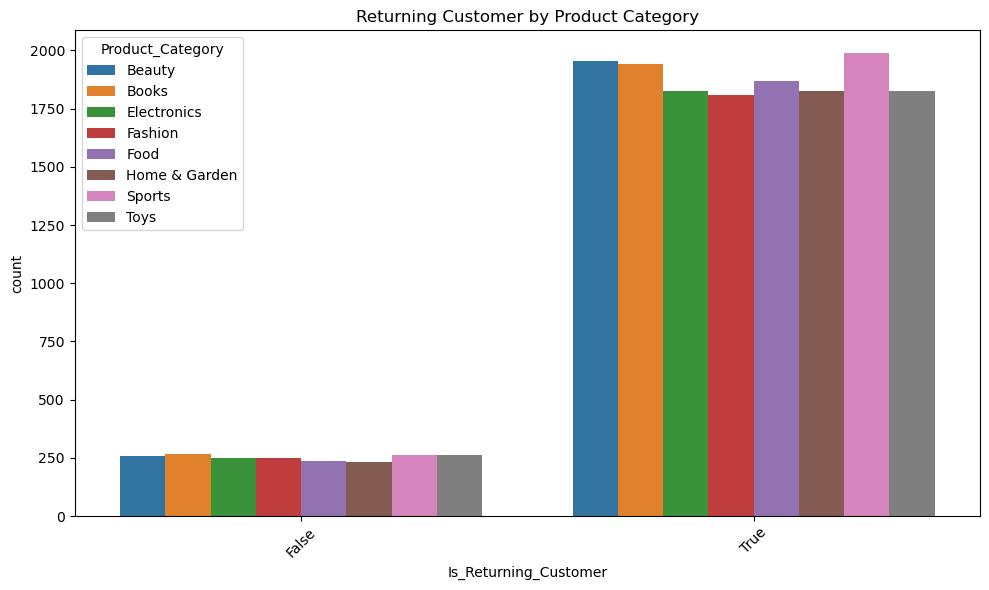

In [22]:
# Here we are determining the size of our graph
plt.figure(figsize=(10,6))

# Here we are determining the data we want on the graph. 
# Hue is used to split our columns into the two seperate genders
sns.countplot(data=df,x='Is_Returning_Customer',hue='Product_Category')

# Here we are using xticks which is used to prevent our labels visuals from becoming a mess
plt.xticks(rotation=45)
plt.title('Returning Customer by Product Category')
plt.tight_layout()
plt.show()

### Boxplot: Returning customers vs Webpage Session Duration

#### For my final analysis as part of the EDA I will be creating a Boxplot to measure the returning/non returning customers by how long they are spending on the website to identify a correlation

#### Here i used similar code layout as in the previous graph, except here im using seaborns boxplot and I am analysing session duration in minutes.

#### It is clear we a can see a relationship between these 2 columns as customers who return to the website will typically spend more time on it that customers that do not.

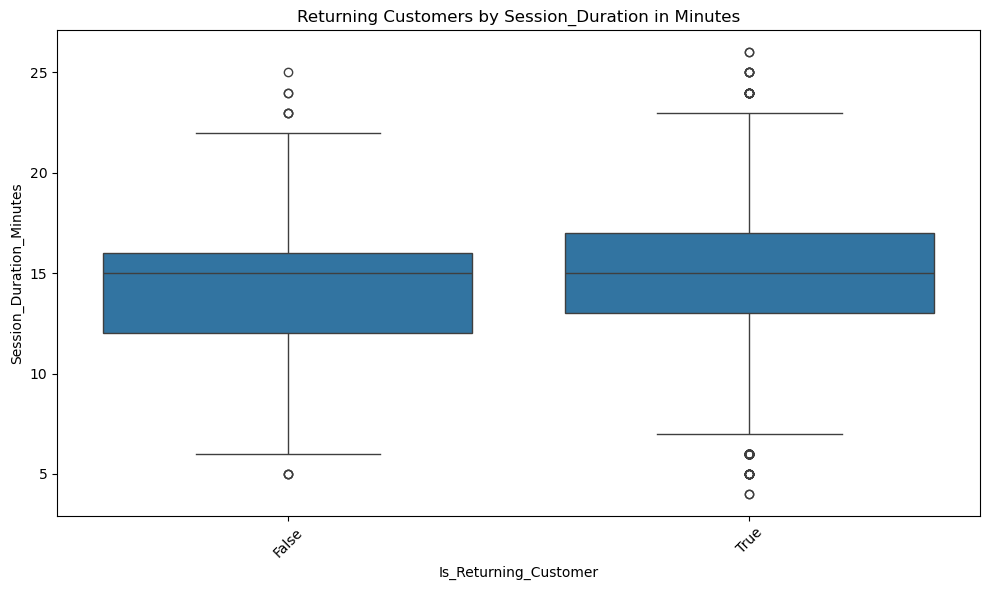

In [23]:
# Here we are determining the size of our graph
plt.figure(figsize=(10,6))

# Here we are determining the data we want on the graph. 
# Hue is used to split our columns into the two seperate genders
sns.boxplot(data=df,x='Is_Returning_Customer',y='Session_Duration_Minutes')

# Here we are using xticks which is used to prevent our labels visuals from becoming a mess
plt.xticks(rotation=45)
plt.title('Returning Customers by Session_Duration in Minutes')
plt.tight_layout()
plt.show()

# Machine Learning

#### To begin this section we will start by Splitting our data but first It is important that all of our object/categorical data is turned into integers as these will allow our Model to better interpret the data.

#### We will preform this action by utilising the encoding function below which utilises .cat.codes which is an accessor in the pandas library that returns integers:

In [24]:
# This function is used to encode the object/categorical data into numerical units (0s and 1s)
def encoding(df):
    for col in df.select_dtypes(include='category'):
        df[col] = df[col].cat.codes
    return df

df = encoding(df)

#### Here we can see we have transformed out datatypes into integers

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17049 entries, 0 to 17048
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       17049 non-null  int64  
 1   Gender                    17049 non-null  int8   
 2   City                      17049 non-null  int8   
 3   Product_Category          17049 non-null  int8   
 4   Unit_Price                17049 non-null  float64
 5   Quantity                  17049 non-null  int64  
 6   Discount_Amount           17049 non-null  float64
 7   Total_Amount              17049 non-null  float64
 8   Payment_Method            17049 non-null  int8   
 9   Device_Type               17049 non-null  int8   
 10  Session_Duration_Minutes  17049 non-null  int64  
 11  Pages_Viewed              17049 non-null  int64  
 12  Is_Returning_Customer     17049 non-null  bool   
 13  Delivery_Time_Days        17049 non-null  int64  
 14  Custom

In [26]:
df.head(3)

,Age,Gender,City,Product_Category,Unit_Price,Quantity,Discount_Amount,Total_Amount,Payment_Method,Device_Type,Session_Duration_Minutes,Pages_Viewed,Is_Returning_Customer,Delivery_Time_Days,Customer_Rating
0,40,1,1,1,29.18,1,0.00,29.18,4,1,14,9,True,13,4
1,40,1,1,5,644.40,1,138.05,506.35,2,0,14,8,True,6,2
2,40,1,1,6,332.82,5,0.00,1664.10,2,1,15,10,True,9,4


## Data Splitting

#### First what I need to do is to create a dataframe with all of the columns except for the Classifier column, which in this case will be the Item Purchased column. And then I create a separate dataframe with only that classifier in it. This needs to be done in order to create our Training and Testing Data

#### To get started here I create 2 data frames, one with all my variables and one specifically for my classifier column. This is important in order to create my Training and my Testing data. To start this, I defined my X data being my classifier and my y data being my variable data frame. I dropped Is_Returning_Customer from my original data frame under X and created Y as a data frame only containing my classifier.


In [27]:
X = df.drop('Is_Returning_Customer', axis=1)  # This will create a DataFrame with all columns except the connection_type
y = df['Is_Returning_Customer']  # This extracts just the class label column

#### I will now begin splitting my dataset into Training Data and Testing Data. I first import my Train_test split function and split up my data into X and y for training and separately X and y for testing. 
#### I set the test size to be only 20% of the data as this is a standard size for measuring test data, next I set my random state as 1 to keep consistent results. Its also very important that we utilise Stratified Sampling in this data splitting because our dataset and classifier is unbalanced, to reduce the likelihood of bias effecting our ML model we use this type of sampling. This is why I have set this to my classifier data frame as ‘y’.

In [28]:
from sklearn.model_selection import train_test_split
# Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1, stratify=y)

#### I also wanted to experiment with different methods of reducing unbalanced classifier bias, a method I adopted in this data analysis was the use of Oversampling (using SMOTE)  and Under Sampling. I created two separate notebooks to test this, one with OverSampling Smote code that aims to fix imbalance by increasing the number of instances within that minority class which in this case with be the customers not returning to the store

In [29]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

# Here I am implementing Smote in order to reduced the unbalanced datasets bias.
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:\n", y_train.value_counts())
print("After SMOTE:\n", y_train_smote.value_counts())

Before SMOTE:
 Is_Returning_Customer
True     12031
False     1608
Name: count, dtype: int64
After SMOTE:
 Is_Returning_Customer
True     12031
False    12031
Name: count, dtype: int64


#### Meanwhile in a separate notebook I utilised Undersampling. This code aimed to fix imbalance by decreasing the number of samples within the majority class which in this case will be the customer returning to the store:  

#### Throughout my separate notebook, I found that utilising Oversampling with SMOTE in my models yielded less biased results than Under sampling, which is why I will be showcasing the Oversampling version of my Machine Learning models going forward in this architecture.



In [30]:
## To utilise Undersampling I simply replace my Smote values and code with the below code.

# from imblearn.under_sampling import RandomUnderSampler

# undersampler = RandomUnderSampler(random_state=42)

# X_train_under, y_train_under = undersampler.fit_resample(X_train, y_train)

#### Now we can see the shape of both training datasets.

In [31]:
print(f' here is the training dataset x : {X_train.shape} and the training dataset y is: {y_train.shape}')

 here is the training dataset x : (13639, 14) and the training dataset y is: (13639,)


#### We have now prepared the main training and testing data so now we can start experimenting with different models, algorithims and Strategies in order to find out the Optimal Model to use.

## Implementing Ensamble Methods

### Random Forest

#### Im utilising Decision Tree and Random Forest as it is a simple dataset that aims to choose the most optimal output based on previous figures and for the number of variables to consider I believed Random Forest was the best choice here.

#### First I imported my Random Forest Classifier model and accuracy score metric. Then I defined my Random Forest classifier with a couple of different parameters. First I selected my n estimators as 20 because I believed that would be a good number of trees that my Random forest algorithm could build and determine the accuracy from. I then set my random state to 42.

In [32]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# RandomForestClassifier
random_forest_model = RandomForestClassifier(n_estimators=20, random_state=42)
random_forest_model.fit(X_train_smote, y_train_smote)


# Ensuring X_test has the same columns in the same order
X_test = X_test[X_train_smote.columns]  

# Predicting the test set results
y_pred = random_forest_model.predict(X_test)

# Calculating the accuracy
accuracy = accuracy_score(y_test, y_pred)

accuracy

0.7392961876832844

In [33]:
X_test.shape

(3410, 14)


### Gradient Boosting
#### Our Random Forest model seemed very accurate, however its important to make sure that our model is taking random subsets of our data samples and choosing the most accurate. However Im using the Gradient Boosting version of this because I want the model to also learn from its inaccuracies to make it more accurate by increasing and decreasing weight of the misclassified samples. 

#### I’m using the Gradient Boosting version of this because I want the model to also learn from its inaccuracies to make it more accurate by increasing and decreasing weight of the misclassified samples.

#### Here I will utilise the Gradient Boosting classifier and setting my parameters as the following: N_estimators = 200 as a good starting off point, my learning rate will be 0.05 as I want to ensure that my model takes small step sizes to minimise its error and therefore potential bias, finally my random state will be 42. 

In [34]:
gb_model = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, random_state=42)

gb_model.fit(X_train_smote, y_train_smote)

y_pred_gb = gb_model.predict(X_test)

#### Now, its time to evaluate how accurate my model was. To evaluate my models going forward, I will call the following actions: accuracy score: to determine how accurate the model is overall, confusion matrix: to gain a better understanding at how accurately and poorly my model makes prediction on if the customer will or won’t return to the website, and my classification report to derive my models precision recall and f1-score figures.

#### Our accuracy score tell us that our model is 67% accurate, however the Confusion Matrix showcases that 117 times the model got a True positive someone will not return to the website however it also identified this falsely 849 times via a False Positive. However we can see that the model has 2159 True Negatives meaning its accurately predicting customers that will return to the website. 

#### The Classification report details our model is very accurate a prediciting users who are returning to the site however is very inaccurate at precision at 0.12 and recall at 0.29 resulting in a poor f1 score of 0.17 or 17% This tells us that only 29 percent of the time the model predicts a customer wont return to the site and only 12% of the time its correct in that predicition. This is because of the data imbalance.

In [35]:
# Evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_gb))
print("Classification Report:\n", classification_report(y_test, y_pred_gb))

Gradient Boosting Accuracy: 0.6674486803519062
Confusion Matrix:
 [[ 117  285]
 [ 849 2159]]
Classification Report:
               precision    recall  f1-score   support

       False       0.12      0.29      0.17       402
        True       0.88      0.72      0.79      3008

    accuracy                           0.67      3410
   macro avg       0.50      0.50      0.48      3410
weighted avg       0.79      0.67      0.72      3410



### Gradient Boosting - Utilising Grid Search Technique.

#### Im utilising this technique because I want to try and find the most optimal parameters to utilise to see if this would improve the models ability to make more accurate predictions. 

#### Here I am defining my parameter grid to find the most optimal parameters. For my n-estimators I want to train 100 decision trees and then I want a separate model training 200 and finding the most optimal outcome. Im using these figures because I have a large number of rows and therefore training this large number of decision trees will yield more accurate results.  I also want to use 0.01, 0.05 and 0.1 learning rates to find the optimal learning rate and finally a introducing the max depth parameter that will limit how deep my decision trees will grow here I will use 3 and 5 as a basis. 
#### Next I set up my grid search with cross validation implemented by using my GridSearchCV object. This is an important object that will try out all of my combinations of parameters in order to evaluate which one works the most accurate. Cv=5 will aim to use 5 fold cross-validations which essentially means it trains 4 parts and tests on 1. Scoring = ‘f1’ will evaluate the models based on their F1 score and n_jobs = -1 helps to speed up the process of grid searching.

#### The original Gradient Boosting model was replaced with a Grid Search technique. approach to optimise hyperparameters. This allowed systematic testing of multiple parameter combinations, improving model performance and robustness.

In [36]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier

# Define parameter grid (factorial experiment)
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5]
}

# Base model
gb = GradientBoostingClassifier(random_state=42)

# Grid Search
grid_search = GridSearchCV(
    estimator=gb,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

# This replaces gb_model.fit(...)
grid_search.fit(X_train_smote, y_train_smote)



,estimator,GradientBoost...ndom_state=42)
,param_grid,"{'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5], 'n_estimators': [100, 200]}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,loss,'log_loss'


#### Below I create a best model function what searches for the best parameters that my model used to yield the most accurate results. This prints out the best parameters it used and then the models best parameters for this model.

In [37]:
# Get best model
best_model = grid_search.best_estimator_

print(best_model) 
print("Best Parameters:", grid_search.best_params_)

GradientBoostingClassifier(max_depth=5, n_estimators=200, random_state=42)
Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}


#### Next I input a piece of code that will utilise that best parameters identified from the previous cell and use it in order to produce an accuracy score, a confusion matrix and a classification report. based on the models predicted and test data.

#### Here we can see that our accuracy score has improved from our previous gradient boosting model from 66% to now being 72% more accurate. However when we analyse the Confusion Matrix and the Classification Report we can see that our models ability to predict customers not returning has actually diminished a bit as now it’s only accurate around 14% of the time according to the F1-score. This tells us that while our parameters are optimised to provide the most accurate score, it’s at the cost of our database suffering from imbalance in customers returning to the store data which our model will aim to predict more of to increase the accuracy at the cost of actually trying to predict customers not returning to the store.

In [38]:
# Predict
y_pred_gb = best_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_gb)

print("Accuracy:", accuracy)
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_gb))
print("Classification Report:\n", classification_report(y_test, y_pred_gb))

Accuracy: 0.7196480938416422
Confusion Matrix:
 [[  78  324]
 [ 632 2376]]
Classification Report:
               precision    recall  f1-score   support

       False       0.11      0.19      0.14       402
        True       0.88      0.79      0.83      3008

    accuracy                           0.72      3410
   macro avg       0.49      0.49      0.49      3410
weighted avg       0.79      0.72      0.75      3410



### Logistical Regression - Price vs User Experience

#### Now I aim to utilise a Logistical Regression model as part of my analysis. My main classifier is categorical and because I am also dealing with attributes that consist of a mix of numerical and categorical data. It will also allow us to implement more methods of having our model become less biased towards the majority classifier.

#### Here I decided to utilise a Logistical Regression model as part of my analysis because it is primarily used in order to predict an event falling between one of 2 categories which my main classifier aims to do. It will also allow us to implement more methods of having our model become less biased towards the majority classifier

#### To begin creating this model, I need to convert the Boolean data of my classifier (True & False) into Binary numbers (0,1) I do this by utilising the “astype(int)” function to convert them from Boolean to binary. I then verify my changes below: 

In [39]:
# First lets check the unique values in my classifier.
df["Is_Returning_Customer"].unique()

array([ True, False])

#### Here im creating a dateframe where our True and False values need to be converted from boolean to binary then I am verifying that conversion by creating a a table below.

In [40]:
df["Returning_Binary"] = df["Is_Returning_Customer"].astype(int)


df[["Is_Returning_Customer","Returning_Binary"]].head()

,Is_Returning_Customer,Returning_Binary
0,True,1
1,True,1
2,True,1
3,True,1
4,True,1


#### For this Logistical regression model, i wanted to reduce the variables bins to a smaller amount of specifc variables to compare how these seperate variables are influencing the model to attribute weight to them and therefore how much they are influencing the customer. 
#### Here I have created 2 seperate bins, one looking at price related data and the other looking at user experience related data.

#### Below this ive also created a total features list and my rtn binary list so i can return the results in binary.

In [41]:
price_features = ["Unit_Price", "Quantity", "Discount_Amount", "Total_Amount"]
ux_features = ["Session_Duration_Minutes", "Pages_Viewed", "Delivery_Time_Days", "Customer_Rating"]

total_features = df[price_features + ux_features]
rtn_binary = df["Returning_Binary"]


#### It is important to highlight that when we split this data, We need to ensure that we utilise Stratified Sampling because our classifier is unbalanced. Stratified sampling ensure more accurate predictions. This is what the stratify=y is doing. My test size ive set to 20% as its a good number of values for testing.

In [42]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    total_features, rtn_binary, test_size=0.2, random_state=42, stratify=y
)

#### Here I am adding Oversampling (SMOTE) into the training of the model in order to reduce Imbalance in the dataset by adding extra samples to the Classifier with the lower value which in this case is the customer not retuning to the stores website.

In [43]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

#### Here i have added Scaling to the model because i need to transform all of my features into the same scale in order to reduce another form of imbalance from taking place. It reduces a "Just Numbers" problem where an AI is like a big calculator that dosent understand just because a number in a column is bigger than another in a seperate column, it dosent mean its more important or influential to the AI its just a number. 
#### For Example: If my Unit Price is 100 and Pages Viewed is 5. The model dosent understand that Unit prices figures and Pages Viewed figures are completley seperate contexts and scenarios and shouldnt be viewed and influenced as "Just numbers" because one has a much larger number than the other. So what scaling aims to do is to address by transforming all of my variables to the same scale.

#### This is what the "scaler.transform" function is doing, implementing the scaler into the training data.

In [44]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#### Here I am actually now training the scaled data under the Logistical Regression Model.

In [45]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


#### Now that it is trained, lets look at our Accuracy score, Confusion Matrix and Classification report 

#### Here we can derive that from training our scaled, oversampled data on our total bin count, we can derive that this model has a similar outcome to our previous models where, its very accurate at prediciting customers that are returning and very poor at accuratley identifying and prediciting customers that are not returning due to the imbalance in the data with out overall model being 57% accurate. 

#### However despite this we actually want to find out what features (Prices vs User Experience) are geting the most influence/weight from this model.

In [46]:
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score, confusion_matrix

# Predictions
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# Metrics
print("Accuracy:", accuracy)
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_gb))
print("Classification Report:\n", classification_report(y_test, y_pred_gb))




Accuracy: 0.7196480938416422
Confusion Matrix:
 [[  70  332]
 [ 640 2368]]
Classification Report:
               precision    recall  f1-score   support

           0       0.10      0.17      0.13       402
           1       0.88      0.79      0.83      3008

    accuracy                           0.71      3410
   macro avg       0.49      0.48      0.48      3410
weighted avg       0.79      0.71      0.75      3410



#### Here Im defining my coefficients function which aims to identify the weighted values each of my variables within by bins have been given.

#### My coefficients function is grabbing the columns names from the combined dataframe i created earlier with my bins combined into one. Then it is identifying eahc co-efficient however I specifiy 0 to tell that i only want 1 derived from each column. which will be the overall weight associated with that column. the code "np.abs(model.coef_[0])" aims to derive the absolute value which is essentially showing us the strength/influence of that column. Then im asking to sort it in decending order.


In [47]:
import pandas as pd
import numpy as np

coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model.coef_[0],
    "Abs_Coefficient": np.abs(model.coef_[0])
})

coefficients = coefficients.sort_values(by="Abs_Coefficient", ascending=False)

print(coefficients)

                    Feature  Coefficient  Abs_Coefficient
7           Customer_Rating     0.294095         0.294095
0                Unit_Price     0.233066         0.233066
3              Total_Amount    -0.203614         0.203614
5              Pages_Viewed     0.192283         0.192283
4  Session_Duration_Minutes     0.159300         0.159300
6        Delivery_Time_Days     0.150470         0.150470
1                  Quantity     0.099513         0.099513
2           Discount_Amount     0.004158         0.004158


#### To conclude my Logistical Regression model, I am calling my features column from the previous cell, then I am applying the Lambda function in order to check if that feature is in the bins I created originally. Then labelling them as either price or User Experience. 

#### Then I am grouping my Price and User Experience type columns and calculating the average absolute co-efficient for each group and displaying it below.

In [48]:
coefficients["Type"] = coefficients["Feature"].apply(
    lambda x: "Price" if x in price_features else "UX"
)

print(coefficients.groupby("Type")["Abs_Coefficient"].mean())

Type
Price    0.135088
UX       0.199037
Name: Abs_Coefficient, dtype: float64


## Artificial Neural Network. - 1. Testing Price variables 

#### What I plan to do in this Artificial Neural Network (ANN)  experiment is to see 2 main things, One I want to analyse how much more accurate I can make my model despite the major imbalance by utilising different types of hidden layers and activation functions. Secondly, I want to use this same architecture on my different features from my previous model. So I’m making one model to test Price, then another to test User Experience and a third utilising both sets of features.

#### I am utilising ANN specifically here because these models are capable of learning complex relationships and uncovering patterns that my previous more simple models couldn’t detect.

#### For the purposes of keeping this section concise I will explain my code for the First model and then for the next 2 ANN models my code architecture is the same throughout, just with changing the bin values and will not be explaining these.

#### To begin my ANN architecture I will import and install essential neural network building blocks/tools like my TensorFlow, Sequential Modelling and importing my layers which will allow all my Input data to connect to each of the neurons.

In [49]:
%pip install tensorflow
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, InputLayer


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


#### Next in order to make the processing of this model more efficient in going to switch my processing of the model from my GPU to my CPU by turning it off. Im also looking for my code to output what version of TensorFlow im using: 

In [50]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

print(tf.__version__)
print(tf.config.list_physical_devices())

2.21.0
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


#### Next I’m going to define new bins for my model (I tried to re-use the bins from the last model and this wasn’t working). In the first cell I am defining my bins with my Price related features/variables (Reminder: This will be the only code that changes through the 3 models). In the second cell I’m splitting the data, this time increasing my test size to 0.2 to encourage more accurate testing results. Then in my third cell in this image I am utilising my Scaler code as seen in my previous model.

In [51]:
# Now we Define X and y for binary logistic regression

X_bin = df[["Unit_Price", "Quantity", "Discount_Amount", "Total_Amount",]]
y_bin = df["Returning_Binary"]

In [52]:
# Spliting the Data for the new model but this time, lets make the test_size smaller.
X_train_smote, X_test_b, y_train_smote, y_test_b = train_test_split(X_bin, y_bin, test_size=0.2, random_state=1, stratify=y)

#### Because this dataset is so large, its important to scale it as we did previously for our last model.

In [53]:
scaler = StandardScaler()
X_train_b = scaler.fit_transform(X_train_smote)
X_test_b = scaler.transform(X_test_b)

#### In the cell below, I begin building my ANN model. I first create the ANN environment in Sequential because It allows me to be able to build my neural network layer by layer which is what I begin doing below this code. 
#### Next I create my Input Layer along with my first hidden layer. The end of the code is where I generate my Input layer, then I’m creating a hidden later where I want my layer to by fully connected with 32 neurons, I’m choosing 32 specifically because it’s a good starting number of summarised weights and input data before the next layer which will be 16 until I get one final output. 
#### For these hidden layers I also choose the activation function: Rectified Linear Unit (ReLU) because it will output 0 for any negative numbers and helps my network understand more complex patterns which is where I’m aiming to find more accurate results from unbalanced data. 
#### Then on my output layer I have chosen the activation function Sigmoid because it outputs variables between 0 and 1 which is what we need since we want to determine if a customer won’t return (0) or will return (1)


In [54]:
# We now build the ANN model using Sequential
model_b = Sequential()

# input layer -> hidden layer 1
model_b.add(Dense(32, activation='relu', input_shape=(X_train_smote.shape[1],)))

# hidden layer 2
model_b.add(Dense(16, activation='relu'))

# output layer for binary classification
model_b.add(Dense(1, activation='sigmoid'))


C:\ProgramData\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


#### Next I need to Compile my model which is where we provide our rules on how the model will learn from the data. Let’s breakdown what I implemented: First I began by creating a compiling function on my model to implement 3 elements, Optimizer, Loss Function my Metrics. 
#### The optimizer “adam” aims to have the model adjust and update its weights during training
#### The Loss function “binary cross-entropy” aims to have the model constantly adjust itself if it makes any incorrect binary related predictions to minimise Loss. I.e. reduce false positives or true negatives
#### The Metrics being accuracy basically allows the model to report its own accuracy metrics but is not influenced by them during training or testing, that’s what the loss functions for.


In [55]:
model_b.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

#### Now I need to train my model, however I also need to set my parameters for training, an important parameter, I need to include is my epochs and batch size. I have set both to 20 in order to ensure I’m not overfitting and so my model has enough reviews of my data before needing to adjust. 20% of my data will be used for validating which will aim to tell me if the models overfitting. Finally verbose is one so my can see my progress bar as it trains.

In [56]:
history = model_b.fit(
    X_train_smote, y_train_smote,
    epochs=20,
    batch_size=20,
    validation_split=0.2,
    verbose=1
)

Epoch 1/20
546/546 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.8384 - loss: 1.5215 - val_accuracy: 0.8864 - val_loss: 0.6648
Epoch 2/20
546/546 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8546 - loss: 0.9878 - val_accuracy: 0.8864 - val_loss: 1.4055
Epoch 3/20
546/546 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8539 - loss: 1.0809 - val_accuracy: 0.8864 - val_loss: 0.7223
Epoch 4/20
546/546 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8610 - loss: 0.7894 - val_accuracy: 0.8446 - val_loss: 0.5923
Epoch 5/20
546/546 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8580 - loss: 1.1481 - val_accuracy: 0.8864 - val_loss: 1.2103
Epoch 6/20
546/546 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8607 - loss: 0.8547 - val_accuracy: 0.7533 - val_loss: 0.7341
Epoch 7/20
546/546 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8644 - loss: 0.6251 - val_accuracy: 0.8864 - val_loss: 1.0071
Epoch 8/20
546/546 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8613 - loss: 0.8619 - val_accuracy: 0.

#### Now that my models trained, let’s predict on my test data. I want my model to classify that if my output is over 0.7 than there is a high likelihood that a customer will return otherwise the customer will likely not return, this code will aim to show how accurately does my model predict this going forward. The reason I am setting the threshold of 0.7 is to encourage my models to identify classifiers of customers that will not return to the store. This will be the same for the rest of the models to keep architecture consistent

In [57]:
# Here Im Predict on test data
yc_pred_prob = model_b.predict(X_test_b)
yc_pred = (yc_pred_prob > 0.7).astype(int)

107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 974us/step


#### Here I am once again utilising the code to derive my Accuracy Score, Confusion Matrix and Classication reports. Below we can see the results of this where our accuracy score is 88% however this is an imbalanced derived figure as out confusion matrix highlights that our model only ever predicted customer returning to the store via the False Negative figure of 3007 and didnt churn the other figure  well at all.

In [58]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


print("\nAccuracy:", accuracy_score(y_test_b, yc_pred))
print("\nConfusion Matrix:\n", confusion_matrix( y_test_b, yc_pred))
print("\nClassification Report:\n", classification_report( y_test_b, yc_pred))


Accuracy: 0.8788856304985337

Confusion Matrix:
 [[   2  400]
 [  13 2995]]

Classification Report:
               precision    recall  f1-score   support

           0       0.13      0.00      0.01       402
           1       0.88      1.00      0.94      3008

    accuracy                           0.88      3410
   macro avg       0.51      0.50      0.47      3410
weighted avg       0.79      0.88      0.83      3410



#### I also wanted to visualise how my model learned overtime by creating a line chart showcasing this by measuring the timeline of how the model was trained versus the Validation Loss of the model. Here I am calling the matplot library and extracting my timeline/history values of the loss and validation loss. 

#### Then I am defining my Epoch value and how this should be represented on the graphy be defining its range.

#### Then I am plotting these on the graph by showing the training loss vs the validation loss where the validation loss and normal loss create and seperate the distinct plots.

#### Then I plot them on the x and y axis and title it and derive the legend.

#### This graph highlights a good learning rate from the training side and a very high learning rate from the validation loss.

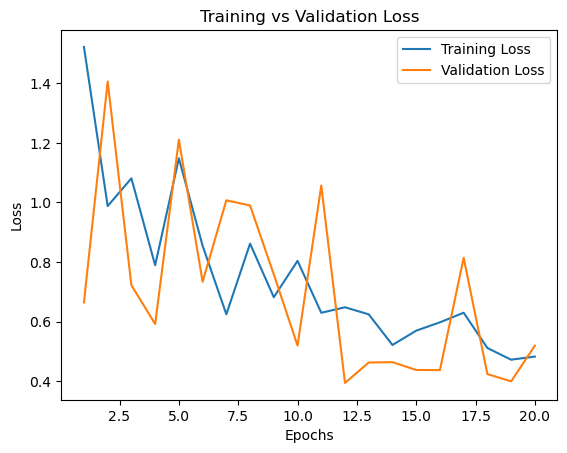

In [59]:
import matplotlib.pyplot as plt
# Extract values
loss = history.history['loss']
val_loss = history.history['val_loss']

# Epoch numbers
epochs = range(1, len(loss) + 1)

# Plot
plt.figure()
plt.plot(epochs, loss, label='Training Loss')
plt.plot(epochs, val_loss, label='Validation Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.show()

### ANN - 2. Testing User Experience variables 

In [60]:
# Now we Define X and y for binary logistic regression

X_bin = df[["Customer_Rating","Session_Duration_Minutes", "Pages_Viewed", "Delivery_Time_Days"]]
y_bin = df["Returning_Binary"]

In [61]:
# Spliting the Data for the new model but this time, lets make the test_size smaller.
X_train_smote, X_test_b, y_train_smote, y_test_b = train_test_split(X_bin, y_bin, test_size=0.2, random_state=1, stratify=y)

In [62]:
scaler = StandardScaler()
X_train_b = scaler.fit_transform(X_train_smote)
X_test_b = scaler.transform(X_test_b)

In [63]:
# We now build the ANN model using Sequential
model_b = Sequential()

# input layer -> hidden layer 1
model_b.add(Dense(32, activation='relu', input_shape=(X_train_smote.shape[1],)))

# hidden layer 2
model_b.add(Dense(16, activation='relu'))

# output layer for binary classification
model_b.add(Dense(1, activation='sigmoid'))

C:\ProgramData\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [64]:
# 5. Compile model
model_b.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [65]:
# 6. Train model
history = model_b.fit(
    X_train_smote, y_train_smote,
    epochs=20,
    batch_size=20,
    validation_split=0.2,
    verbose=1
)

Epoch 1/20
546/546 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8808 - loss: 0.3774 - val_accuracy: 0.8864 - val_loss: 0.3693
Epoch 2/20
546/546 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8810 - loss: 0.3707 - val_accuracy: 0.8864 - val_loss: 0.3814
Epoch 3/20
546/546 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8810 - loss: 0.3705 - val_accuracy: 0.8864 - val_loss: 0.3562
Epoch 4/20
546/546 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8810 - loss: 0.3697 - val_accuracy: 0.8864 - val_loss: 0.3609
Epoch 5/20
546/546 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8810 - loss: 0.3700 - val_accuracy: 0.8864 - val_loss: 0.3563
Epoch 6/20
546/546 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8810 - loss: 0.3686 - val_accuracy: 0.8864 - val_loss: 0.3577
Epoch 7/20
546/546 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8810 - loss: 0.3683 - val_accuracy: 0.8864 - val_loss: 0.3631
Epoch 8/20
546/546 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8810 - loss: 0.3679 - val_accuracy: 0.

In [66]:
# 7. Predict on test data
yc_pred_prob = model_b.predict(X_test_b)
yc_pred = (yc_pred_prob > 0.7).astype(int)

107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 936us/step


In [67]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 8. Evaluate
print("\nAccuracy:", accuracy_score(y_test_b, yc_pred))
print("\nConfusion Matrix:\n", confusion_matrix( y_test_b, yc_pred))
print("\nClassification Report:\n", classification_report( y_test_b, yc_pred))


Accuracy: 0.6023460410557184

Confusion Matrix:
 [[ 120  282]
 [1074 1934]]

Classification Report:
               precision    recall  f1-score   support

           0       0.10      0.30      0.15       402
           1       0.87      0.64      0.74      3008

    accuracy                           0.60      3410
   macro avg       0.49      0.47      0.45      3410
weighted avg       0.78      0.60      0.67      3410



#### Comparing this model to the previous one, we do see a level of improvement where it’s actually detecting both customers returning and not returning and a more balance recall overall. However at the cost of accuracy dropping to 53%. This tells us that Customer Experience contains more predictive information than the Price as we deduced from the Logistical regression model.

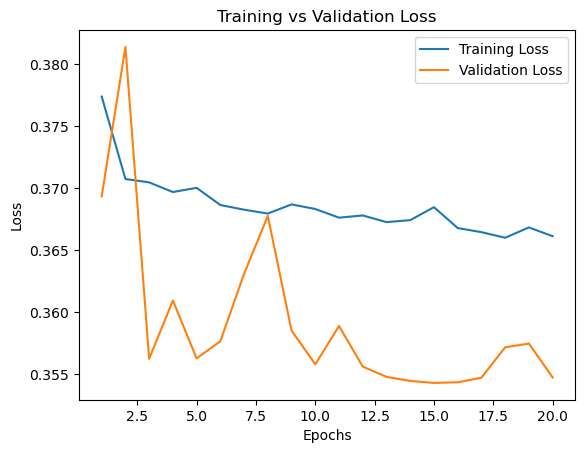

In [68]:
import matplotlib.pyplot as plt
# Extract values
loss = history.history['loss']
val_loss = history.history['val_loss']

# Epoch numbers
epochs = range(1, len(loss) + 1)

# Plot
plt.figure()
plt.plot(epochs, loss, label='Training Loss')
plt.plot(epochs, val_loss, label='Validation Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.show()

### ANN - 3. Testing Price + User Experience variables 

In [69]:
# Now we Define X and y for binary logistic regression

X_bin = df[["Customer_Rating","Session_Duration_Minutes", "Pages_Viewed", "Delivery_Time_Days",
           "Unit_Price", "Quantity", "Discount_Amount", "Total_Amount"]]
y_bin = df["Returning_Binary"]

In [70]:
# Spliting the Data for the new model but this time, lets make the test_size smaller.
X_train_smote, X_test_b, y_train_smote, y_test_b = train_test_split(X_bin, y_bin, test_size=0.2, random_state=1, stratify=y)

In [71]:
scaler = StandardScaler()
X_train_b = scaler.fit_transform(X_train_smote)
X_test_b = scaler.transform(X_test_b)

In [72]:
# We now build the ANN model using Sequential
model_b = Sequential()

# input layer -> hidden layer 1
model_b.add(Dense(32, activation='relu', input_shape=(X_train_smote.shape[1],)))

# hidden layer 2
model_b.add(Dense(16, activation='relu'))

# output layer for binary classification
model_b.add(Dense(1, activation='sigmoid'))

C:\ProgramData\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [73]:
# 5. Compile model
model_b.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [74]:
# 6. Train model
history = model_b.fit(
    X_train_smote, y_train_smote,
    epochs=20,
    batch_size=20,
    validation_split=0.2,
    verbose=1
)

Epoch 1/20
546/546 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8036 - loss: 17.9802 - val_accuracy: 0.4168 - val_loss: 4.4402
Epoch 2/20
546/546 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8344 - loss: 2.0923 - val_accuracy: 0.8860 - val_loss: 0.7796
Epoch 3/20
546/546 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8311 - loss: 1.6397 - val_accuracy: 0.8864 - val_loss: 2.0483
Epoch 4/20
546/546 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8436 - loss: 1.4302 - val_accuracy: 0.6987 - val_loss: 1.0433
Epoch 5/20
546/546 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8419 - loss: 1.9547 - val_accuracy: 0.8864 - val_loss: 1.6696
Epoch 6/20
546/546 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8487 - loss: 1.3058 - val_accuracy: 0.8677 - val_loss: 0.5087
Epoch 7/20
546/546 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8456 - loss: 1.2566 - val_accuracy: 0.8259 - val_loss: 0.5410
Epoch 8/20
546/546 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8399 - loss: 1.3212 - val_accuracy: 0

In [75]:
yc_pred_prob = model_b.predict(X_test_b)
yc_pred = (yc_pred_prob > 0.7).astype(int)

107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 993us/step


In [76]:
# 8. Evaluate
print("\nAccuracy:", accuracy_score(y_test_b, yc_pred))
print("\nConfusion Matrix:\n", confusion_matrix( y_test_b, yc_pred))
print("\nClassification Report:\n", classification_report( y_test_b, yc_pred))


Accuracy: 0.17565982404692082

Confusion Matrix:
 [[ 369   33]
 [2778  230]]

Classification Report:
               precision    recall  f1-score   support

           0       0.12      0.92      0.21       402
           1       0.87      0.08      0.14      3008

    accuracy                           0.18      3410
   macro avg       0.50      0.50      0.17      3410
weighted avg       0.79      0.18      0.15      3410



#### This third and final model has now provided an opposite issue where previously it was recalling the likelihood of customers returning too often due to the imbalance, now its predicting the likelihood customers will not return almost every time and is still getting the vast majority of them wrong. This tells us that combining features together heavily influences the model sensitivity and only amplifies the likelihood of imbalance.

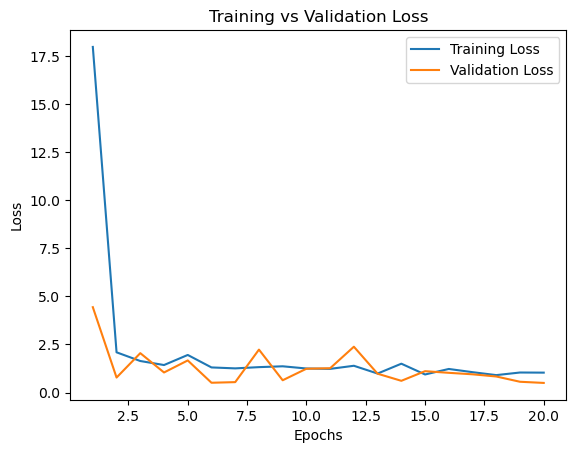

In [77]:
# Extract values
loss = history.history['loss']
val_loss = history.history['val_loss']

# Epoch numbers
epochs = range(1, len(loss) + 1)

# Plot
plt.figure()
plt.plot(epochs, loss, label='Training Loss')
plt.plot(epochs, val_loss, label='Validation Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.show()